# Layer 1 Gatekeeper Model Training

This notebook trains a fast binary classifier (lightGBM) to act as a gatekeeper.
It classifies traffic into `0` (Normal) and `1` (Suspicious) before sending it to Layer 2.

In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import os

print("Libraries loaded.")

Libraries loaded.


### 1. Load the CIC-IDS-2017 Dataset and Custom PCAP Data

In [2]:
# 1. Load original dataset
df_original = pd.read_csv('../data/processed/cicids2017_cleaned.csv')
print(f"Original dataset shape: {df_original.shape}")

# 2. Load custom PCAP data (if generated by pcap_to_csv.py)
custom_csv = '../data/processed/custom_normal_traffic.csv' 

if os.path.exists(custom_csv):
    df_custom = pd.read_csv(custom_csv)
    print(f"Loaded custom normal traffic with {len(df_custom)} flows.")
    
    # Append to original
    df_combined = pd.concat([df_original, df_custom], ignore_index=True)
else:
    print("Custom CSV not found. Proceeding with only the original dataset.")
    df_combined = df_original

print(f"Total dataset shape: {df_combined.shape}")

Original dataset shape: (2520751, 53)
Loaded custom normal traffic with 28785 flows.
Total dataset shape: (2549536, 53)


### 2. Map Labels to Binary (0 = Normal, 1 = Suspicious)

In [3]:
def map_to_binary(label):
    # If it's Normal Traffic, return 0. Otherwise return 1 (Suspicious)
    if 'Normal' in str(label) or 'BENIGN' in str(label):
        return 0
    return 1

df_combined['Is_Suspicious'] = df_combined['Attack Type'].apply(map_to_binary)

print("Label Distribution for Layer 1:")
print(df_combined['Is_Suspicious'].value_counts(normalize=True) * 100)

Label Distribution for Layer 1:
Is_Suspicious
0    83.303079
1    16.696921
Name: proportion, dtype: float64


### 3. Train the Fast Decision Tree Classifier

In [ ]:
import lightgbm as lgb

# 1. Drop the label columns (Keep ALL 47 features!)
X = df_combined.drop(['Attack Type', 'Is_Suspicious'], axis=1, errors='ignore')
y = df_combined['Is_Suspicious']

# Ensure we only use numeric features
X = X.select_dtypes(include=[np.number])

# 2. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\nTraining the upgraded Gatekeeper Model (LightGBM Binary Classifier) on ALL features...")
clf = lgb.LGBMClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

print("Training Complete!")



Training the upgraded Gatekeeper Model (LightGBM Binary Classifier) on ALL features...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 340555, number of negative: 1699073
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.219451 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12082
[LightGBM] [Info] Number of data points in the train set: 2039628, number of used features: 52
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.166969 -> initscore=-1.607261
[LightGBM] [Info] Start training from score -1.607261
Training Complete!


### 4. Evaluate Performance

Classification Report:
                precision    recall  f1-score   support

    Normal (0)       1.00      1.00      1.00    424769
Suspicious (1)       1.00      1.00      1.00     85139

      accuracy                           1.00    509908
     macro avg       1.00      1.00      1.00    509908
  weighted avg       1.00      1.00      1.00    509908



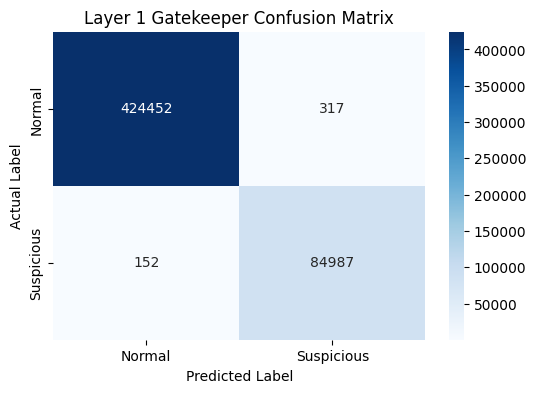

In [5]:
y_pred = clf.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal (0)', 'Suspicious (1)']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Suspicious'], yticklabels=['Normal', 'Suspicious'])
plt.title('Layer 1 Gatekeeper Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### 5. Save the Model

In [ ]:
model_path = '../src/models/lightgbm1_model.pkl'
features_path = '../src/models/lightgbm1_features.pkl'

joblib.dump(clf, model_path)
joblib.dump(list(X.columns), features_path)

print(f"Layer 1 model saved to {model_path}")
print(f"Layer 1 features saved to {features_path}")

Layer 1 model saved to ../src/models/layer1_model.pkl
Layer 1 features saved to ../src/models/layer1_features.pkl
